# Week 10: Model Validation
## Project Tasks:
- Apply Stratified K-Fold cross-validation to all models
- Hyperparameter tuning (GridSearch/RandomizedSearch)
- Build model comparison table

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")

from minilearn import StandardScaler, train_test_split
from minilearn import KNNClassifier, accuracy_score
from minilearn import k_fold_split

from sklearn.neighbors import KNeighborsClassifier as SKKNN
from sklearn.linear_model import LogisticRegression as SKLogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

In [2]:
fpath = os.path.join("../data", "week5_audio.csv")

feature_df = pd.read_csv(fpath)

feature_df.head()

,mfcc_1_mean,mfcc_1_std,mfcc_1_min,mfcc_1_max,mfcc_2_mean,mfcc_2_std,mfcc_2_min,mfcc_2_max,mfcc_3_mean,mfcc_3_std,...,spectral_rolloff_std,spectral_rolloff_min,spectral_rolloff_max,path,filename,emotion,intensity,actor,gender,vocal_channel
0,-726.21720,157.85083,-861.53260,-432.15480,68.54142,84.219345,-85.970474,236.70389,3.293398,20.393255,...,7873.634242,0.0000,20929.6875,../data/Actor_01/03-01-01-01-01-01-01.wav,03-01-01-01-01-01-01.wav,neutral,normal,1,male,speech
1,-719.12830,159.35600,-861.44400,-417.70416,70.20157,78.612820,-14.972853,218.36372,1.168397,23.063353,...,7634.107567,960.9375,21140.6250,../data/Actor_01/03-01-01-01-01-02-01.wav,03-01-01-01-01-02-01.wav,neutral,normal,1,male,speech
2,-714.99570,162.87424,-851.23380,-412.74353,69.68935,85.796005,-45.141598,229.02920,3.924564,17.979307,...,7981.393363,0.0000,21140.6250,../data/Actor_01/03-01-01-01-02-01-01.wav,03-01-01-01-02-01-01.wav,neutral,normal,1,male,speech
3,-710.97530,161.77583,-847.86710,-388.34793,67.56488,78.593960,-37.103306,216.24066,5.782241,20.279503,...,7570.671093,937.5000,21187.5000,../data/Actor_01/03-01-01-01-02-02-01.wav,03-01-01-01-02-02-01.wav,neutral,normal,1,male,speech
4,-759.92175,162.98659,-917.40265,-454.39650,75.78352,78.566280,-18.632597,230.43222,6.023605,23.161620,...,7902.073642,0.0000,21585.9375,../data/Actor_01/03-01-02-01-01-01-01.wav,03-01-02-01-01-01-01.wav,calm,normal,1,male,speech


In [3]:
m_cols = ["path", "filename", "emotion", "intensity", "actor", "gender", "vocal_channel"]
f_cols = []

for c in feature_df.columns:
    if c not in m_cols:
        f_cols.append(c)

X = feature_df[f_cols]
y = feature_df["emotion"]

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.2,stratify=y)
X_train_full = np.array(X_train_full, dtype=float)
X_test = np.array(X_test, dtype=float)
y_train_full = np.array(y_train_full)
y_test = np.array(y_test)

In [5]:
folds = k_fold_split(y_train_full, n_splits=5, shuffle=False)

for i in range(len(folds)):
    train_idx, val_idx = folds[i]

In [6]:
def cv_model(make_model, X_data, y_data, folds):
    scores = []

    for train_idx, val_idx in folds:
        X_train = X_data[train_idx]
        X_val = X_data[val_idx]
        y_train = y_data[train_idx]
        y_val = y_data[val_idx]
        scaler = StandardScaler()
        X_train_scale = scaler.fit_transform(X_train)
        X_val_scale = scaler.transform(X_val)

        model = make_model()
        model.fit(X_train_scale, y_train)
        pred = model.predict(X_val_scale)
        scores.append(accuracy_score(y_val, pred))

    return np.array(scores)



In [7]:
models = [["MiniLearn KNN", lambda: KNNClassifier(n_neighbors=5), "k=5"], ["SKlearn KNN", lambda: SKKNN(n_neighbors=5), "k=5"], ["SKlearn Logistic Regression", lambda: SKLogisticRegression(max_iter=5000), "max_iter=5000"]]

cv_results = []

for row in models:
    name = row[0]
    make_model = row[1]
    parameters = row[2]
    scores = cv_model(make_model, X_train_full, y_train_full, folds)

    cv_results.append({"model": name, "parameters": parameters, "mean_cv_accuracy": np.mean(scores), "std_cv_accuracy": np.std(scores), "fold_scores": np.round(scores, 3)})

cv_df = pd.DataFrame(cv_results)
cv_df = cv_df.sort_values("mean_cv_accuracy", ascending=False)

cv_df

,model,parameters,mean_cv_accuracy,std_cv_accuracy,fold_scores
2,SKlearn Logistic Regression,max_iter=5000,0.647002,0.019052,"[0.645, 0.661, 0.62, 0.635, 0.674]"
0,MiniLearn KNN,k=5,0.506817,0.016068,"[0.534, 0.49, 0.5, 0.495, 0.515]"
1,SKlearn KNN,k=5,0.506817,0.016068,"[0.534, 0.49, 0.5, 0.495, 0.515]"


In [8]:
k_results = []

for k in [1, 3, 5, 7, 9, 11]:
    scores = cv_model(lambda k=k: KNNClassifier(n_neighbors=k), X_train_full, y_train_full, folds)
    k_results.append({"k": k, "mean_cv_accuracy": np.mean(scores), "std_cv_accuracy": np.std(scores)})

k_df = pd.DataFrame(k_results)
k_df = k_df.sort_values("mean_cv_accuracy", ascending=False)

k_df

,k,mean_cv_accuracy,std_cv_accuracy
0,1,0.589383,0.027476
1,3,0.523684,0.006317
2,5,0.506817,0.016068
3,7,0.492615,0.006270
5,11,0.490632,0.013944
4,9,0.485482,0.016094


Text(0, 0.5, 'Mean CV Accuracy')

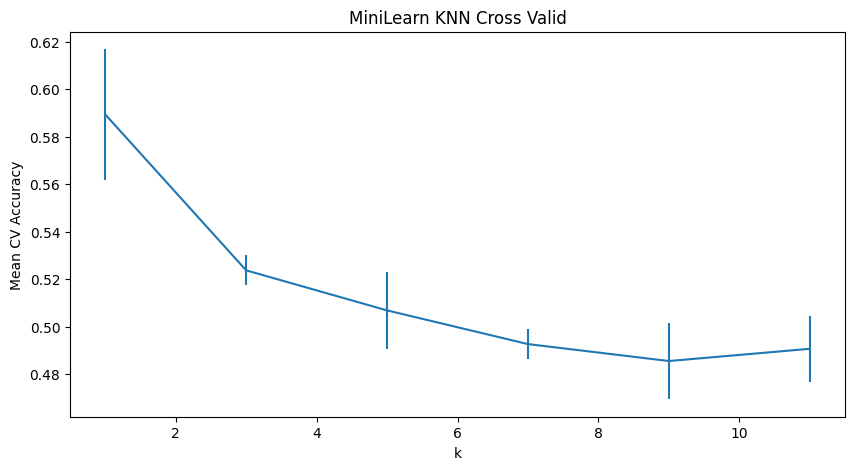

In [9]:
plt.figure(figsize=(10,5))
plot_df = k_df.sort_values("k")
plt.errorbar(plot_df["k"], plot_df["mean_cv_accuracy"], yerr=plot_df["std_cv_accuracy"])
plt.title("MiniLearn KNN Cross Valid")
plt.xlabel("k")
plt.ylabel("Mean CV Accuracy")